<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Word Vectors From Counting</b>
</h1>
<div style="font-family:'Times New Roman';">
The count then compress method on a real corpus. Build a co-occurrence matrix from the Brown corpus, take the log, run SVD, and check whether the nearest neighbours of a word actually make sense.
</div>

In [1]:
import numpy as np
import collections
import matplotlib.pyplot as plt
import nltk

nltk.download('brown', quiet=True)
from nltk.corpus import brown

sents = [[w.lower() for w in s if w.isalpha()]
         for s in brown.sents(categories=['news', 'fiction', 'romance', 'adventure'])]

print("sentences :", len(sents))
print("words     :", sum(len(s) for s in sents))
print(" ".join(sents[0][:15]))

sentences : 17940
words     : 254163
the fulton county grand jury said friday an investigation of recent primary election produced no


## vocabulary

keeping only the 3000 most common words. rare words dont appear enough times for their counts to mean anything.

In [2]:
counts = collections.Counter(w for s in sents for w in s)
V = [w for w, n in counts.most_common(3000)]
idx = {w: i for i, w in enumerate(V)}

print("vocab :", len(V))
print("most common :", V[:12])
print("least common kept :", V[-8:], " count of the last one :", counts[V[-1]])

vocab : 3000
most common : ['the', 'and', 'of', 'to', 'a', 'in', 'he', 'was', 'his', 'that', 'it', 'had']
least common kept : ['elder', 'holmes', 'mess', 'raced', 'mckinley', 'disappeared', 'waves', 'hatred']  count of the last one : 9


## the co-occurrence matrix

for every word, count how often each other word appears within 4 positions of it. 3000 x 3000 is fine to hold in memory, a full vocabulary would not be.

In [3]:
N = len(V)
C = np.zeros((N, N), dtype=np.float32)
WINDOW = 4

for s in sents:
    ids = [idx[w] for w in s if w in idx]
    for i, w in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if i != j:
                C[w, ids[j]] += 1

print("matrix :", C.shape)
print("filled cells :", round(100 * (C > 0).mean(), 2), "%  (so mostly zeros)")

matrix : (3000, 3000)
filled cells : 4.43 %  (so mostly zeros)


In [4]:
row = C[idx['school']]
top = np.argsort(-row)[:10]
print("words appearing near 'school' :")
for i in top:
    print("  ", V[i].ljust(10), int(row[i]))

words appearing near 'school' :
   the        75
   and        41
   to         39
   in         38
   a          34
   of         30
   high       29
   at         22
   was        16
   from       13


the top neighbours are `the`, `of`, `and`. those appear near everything so they carry no information. taking a log squashes the huge counts and helps a bit.

In [5]:
M = np.log1p(C)      # log(1 + count)
print("before log, biggest cell :", int(C.max()))
print("after  log, biggest cell :", round(float(M.max()), 2))

before log, biggest cell : 7006
after  log, biggest cell : 8.85


## SVD

each row is 3000 long. SVD finds the directions that explain the most and lets me keep only the first 100.

singular values : (3000,)


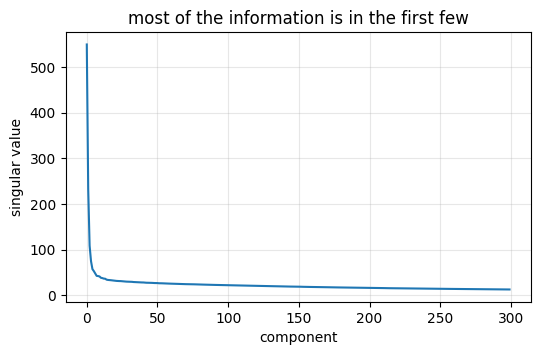

In [7]:
U, S, Vt = np.linalg.svd(M, full_matrices=False)
print("singular values :", S.shape)

plt.figure(figsize=(6,3.5))
plt.plot(S[:300])
plt.xlabel('component'); plt.ylabel('singular value')
plt.title('most of the information is in the first few')
plt.grid(alpha=.3)
plt.show()

In [9]:
D = 100
E = U[:, :D] * S[:D]
E = E / np.linalg.norm(E, axis=1, keepdims=True)     # normalise so cosine is just a dot product

print("embedding matrix :", E.shape, " so", D, "numbers per word instead of", N)

embedding matrix : (3000, 100)  so 100 numbers per word instead of 3000


## nearest neighbours
this is the real test. if the vectors mean anything then the closest words should be related.

In [18]:
def nearest(word, k=6):
    if word not in idx:
        return ["not in vocab"]
    sims = E @ E[idx[word]]
    order = np.argsort(-sims)[1:k+1]      # skip itself
    return [V[i] for i in order]

for w in ['three', 'red', 'man', 'city', 'school', 'water']:
    print(w.ljust(8), "->", nearest(w))

three    -> ['four', 'five', 'two', 'days', 'six', 'few']
red      -> ['black', 'lines', 'thin', 'gray', 'blue', 'thick']
man      -> ['old', 'young', 'girl', 'woman', 'himself', 'even']
city     -> ['board', 'president', 'school', 'public', 'company', 'american']
school   -> ['high', 'city', 'next', 'college', 'past', 'work']
water    -> ['still', 'dark', 'turned', 'fire', 'eyes', 'light']


`three` gives four, five, two. `red` gives black, blue, gray. those are clean.

now the ones that are not so good:

In [13]:
for w in ['war', 'doctor', 'money', 'music']:
    print(w.ljust(8), "->", nearest(w))

war      -> ['instead', 'team', 'cold', 'fight', 'world', 'office']
doctor   -> ['alone', 'call', 'stand', 'name', 'boy', 'baby']
money    -> ['life', 'work', 'town', 'way', 'best', 'great']
music    -> ['doctor', 'dandy', 'safe', 'book', 'weather', 'de']


`doctor` and `money` come back with fairly random words. my first guess was that they are just rarer, so i checked the counts.

In [14]:
for w in ['three', 'red', 'doctor', 'money']:
    print(w.ljust(8), "appears", counts[w], "times")

three    appears 192 times
red      appears 58 times
doctor   appears 56 times
money    appears 89 times


and that guess was wrong. `red` appears 58 times and gives clean neighbours, `doctor` appears 56 times and gives junk. almost the same count, completly diffrent quality.

so its not frequency, its **how consistent the contexts are**. a colour word almost always sits in the same slot, right before a noun and often near other colours, so its row in the matrix has a clear shape. `doctor` turns up in every kind of sentence, so its row is spread thin over many unrelated words and the average of that is noise.

either way 56 counts is nothing. real word vectors are trained on billions of words, my whole corpus is about 400 thousand.

## seeing it in 2d

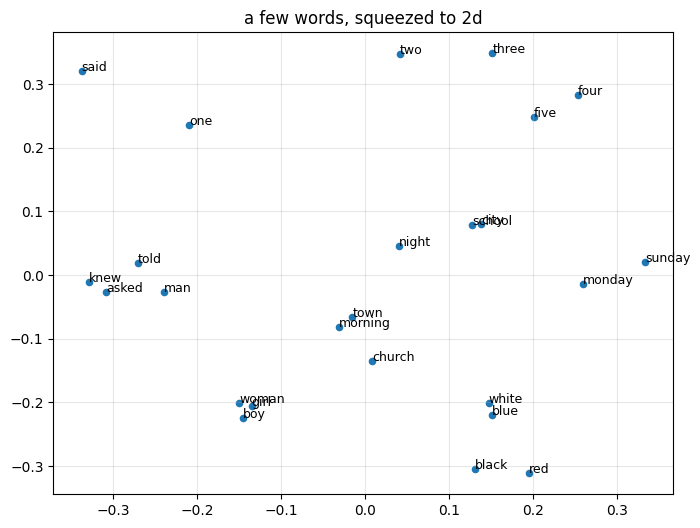

In [16]:
show = ['one','two','three','four','five',
        'red','black','white','blue',
        'man','woman','boy','girl',
        'city','town','school','church',
        'said','asked','told','knew',
        'monday','sunday','morning','night']
show = [w for w in show if w in idx]

sub = E[[idx[w] for w in show]]
flat = np.linalg.svd(sub - sub.mean(0))[0][:, :2] * 1.0

plt.figure(figsize=(8,6))
plt.scatter(flat[:,0], flat[:,1], s=20)
for w, p in zip(show, flat):
    plt.annotate(w, p, fontsize=9)
plt.title('a few words, squeezed to 2d')
plt.grid(alpha=.3)
plt.show()

numbers sit together, colours sit together, days and times sit together. the grouping was never told to the model, it fell out of counting alone.

### what i learned

- a row of the co-occurrence matrix is already a word vector, just very long and sparse
- log helps because the raw counts are dominated by `the` and `of`
- SVD takes it from 3000 numbers down to 100 and the meaning survives
- quality is not about the count, its about whether the word appears in consistent contexts. `red` with 58 counts beats `doctor` with 56
- no gradient descent anywhere in this notebook, its one matrix and one SVD. word2vec in notebook 03 learns the same thing instead of counting it